# All in one 

1. Read all picks in a folder
2. plot waveforms based on selected HS and phase 
3. plot envelope based on selected HS and phase 
4. export into CSV
5. pick slopes
6. do UMAP with smgr or envelope 

## Load modules

In [1]:
import numpy as np
import pandas as pd
import math

import ipywidgets

import glob
import os
import re

import matplotlib.pylab as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from obspy import read, UTCDateTime
import obspy.signal.filter

from scipy.fftpack import fft, fftfreq, next_fast_len

from bokeh.io import output_notebook
from bokeh.plotting import figure, show, ColumnDataSource
from bokeh.models import HoverTool
import matplotlib as mpl

import umap.plot

%load_ext autoreload
%autoreload 2
%matplotlib inline 
%matplotlib widget

/home/sam/miniforge3/envs/mth3035/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:359: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/sam/miniforge3/envs/mth3035/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:359: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
/home/sam/miniforge3/envs/mth3035/lib/python3.11/site-packages/numba/np/ufunc/dufunc.py:359: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
 

## Functions

In [2]:
def calculate_distance(point1, point2):
    # Unpack points
    x1, y1 = point1
    x2, y2 = point2
    
    # Calculate the distance
    distance = math.sqrt((x2 - x1)**2 + (y2 - y1)**2)
    
    return distance

# Function to calculate Euclidean distance from point (px, py) to (x, y)
def calculate_distance_df(row, px, py):
    return np.sqrt((row['lon'] - px) ** 2 + (row['lat'] - py) ** 2)

def calculate_distance(row):
    dlon = row['ev_lon'] - row['lon']
    dlat = row['ev_lat'] - row['lat']
    distance = np.sqrt(dlon**2 + dlat**2)
    return distance

def plot_spectrum(tr):
    """Plot spectrum of ObsPy trace"""
    tr.detrend('demean')
    #tr.taper(0.5, 'hann')   
    sr = tr.stats.sampling_rate
    nfft = next_fast_len(tr.stats.npts)  # pad data with zeros for fast FT
    pos_freq = (nfft + 1) // 2  # index for positive frequencies
    spec = fft(tr.data, nfft)[:pos_freq]
    freq = fftfreq(nfft, 1 / sr)[:pos_freq]  # get freqs of DFT bin
    return freq, spec 

def onclick(event):
    if event.inaxes != ax:
        return
    points.append((event.xdata, event.ydata))
    if len(points) == 2:
        x1, y1 = points[0]
        x2, y2 = points[1]
        slope = (x2 - x1) / (y2 - y1)
        print(f"Point 1: ({x1}, {y1})")
        print(f"Point 2: ({x2}, {y2})")
        print(f"Slope: {slope}")
        points.clear()  # Clear points to allow for new selection

def extract_digits_from_substring(s, pattern):
    # Use regular expression to find the pattern
    match = re.search(pattern, s)
    
    if match:
        # Extract the digits from the matched pattern
        digits = re.findall(r'\d+', match.group())
        return int(digits[0]) if digits else None
    return None

def determine_orientation(row):
    if len(set(row[['ev_lat', 'lat']])) == 1:
        return 'Horizontal'
    elif len(set(row[['ev_lon', 'lon']])) == 1:
        return 'Vertical'
    else:
        return 'None'



## Paths and Input

In [3]:
# not well picked
path_to_strikewise_folder = "strike_wise"
picks_file_name = "PICKS_LAST_YEAR/*.txt"

# path_to_strikewise_folder = "/Users/tnm/Dropbox/TEACHING_dropbox/EXETER/MHT3035/SoultonHall/MTH3035_archeogeophysics/strike_wise"
# picks_file_name = "/Users/tnm/Dropbox/TEACHING_dropbox/EXETER/MHT3035/SoultonHall/TNM_DATA_ANALYSIS/*.txt"

# for saving outputs 
save_path = os.path.dirname(picks_file_name)

selected_hs = 8
selectes_phase = 'S'
umap_type = 'seismogram' # 'envelope' or 'seismogram' 

# for plotting seismograms 
min_exp = 8  # put to -1 and 
max_exp = 8 # put to 99 to include all picks

# select station distances to source 

min_dist_2_source = 1  # max meters away from source; put to 0 and 99 to include all picksto include all picks 
max_dist_2_source = 6  # max meters away from source 
filter = [False, 10, 50]  # for plotting seismograms 

## Read all picks in folder

In [4]:
# Load picks 
path_to_picks = glob.glob(picks_file_name)
path_to_picks.sort()

collect_picks = []

for pick_path in path_to_picks:
    
    pattern = r'HS\d{2}'  # Pattern to match "HS" followed by two digits
    number_hammer_strike = extract_digits_from_substring(pick_path, pattern)
    print(pick_path)
    print(pattern)
    print(number_hammer_strike)
    # Load station info
    station_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/station_info_HS{number_hammer_strike:02d}.txt"))[0]
    sta_locs = pd.read_csv(station_info, header=None, comment="#", sep='\s+', names=['sta', 'lat', 'lon', 'elev', 'depth'])
    sta_locs['sta'] = sta_locs['sta'].str.replace(r'^SH\.|.$', '', regex=True)

    # Ensure 'sta' column in sta_locs is unique
    sta_locs = sta_locs.drop_duplicates(subset=['sta'])

    # Load 'event' info 
    event_info = glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/event_info_HS{number_hammer_strike:02d}.txt"))[0]
    event = {}
    file1 = open(event_info, 'r')
    Lines1 = file1.readlines()
    for line in Lines1:
        if "longitude" in line.strip():
            event['longitude'] = float(line.strip().split('=')[1])
        elif "latitude" in line.strip():
            event['latitude'] = float(line.strip().split('=')[1])
        else:
            pass

    # put everything together into a pandas data frame 
    file = pick_path
    file2 = open(file, 'r')
    Lines2 = file2.readlines()
    count = 0

    session = 1  # Hard coded
    # phase = 'S'
    experiment = number_hammer_strike
    # Strips the newline character
    for line in Lines2:
        count += 1
        if "phase" in line.strip():
            strip_line = line.strip().split()
            try:
                net, sta, loc, cha = strip_line[4].split('.')
            except Exception as exp:
                print(exp)

            if len(strip_line[8]) > 1:
                print(f"Probably a time window instead of phase: {strip_line[8]}")
                continue

            collect_picks.append([UTCDateTime(f"{strip_line[1]}T{strip_line[2]}"), session, experiment, net, sta, strip_line[8], event['latitude'], event['longitude']])

df_picks = pd.DataFrame(collect_picks, columns = ['datetime',  'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat', 'ev_lon']) 

# # Merge the two DataFrames based on the 'sta' column
df_picks = pd.merge(df_picks, sta_locs, on='sta', how='left')

# # Apply the function to each row and save the result in a new column
# df_picks['distance_to_source'] = df_picks.apply(calculate_distance_df, axis=1, px=event['longitude'], py=event['latitude'])
df_picks['distance_to_source'] = df_picks.apply(calculate_distance, axis=1)

df_picks['orientation'] = df_picks.apply(determine_orientation, axis=1)

print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("\tUnique experiments:", df_picks['experiment'].unique())
print("Number of unique stations:", len(df_picks['sta'].unique()))
df_picks.head()

# df_picks['experiment'].value_counts().sort_index()

PICKS_LAST_YEAR/HS01.txt
HS\d{2}
1
PICKS_LAST_YEAR/HS02.txt
HS\d{2}
2
PICKS_LAST_YEAR/HS03.txt
HS\d{2}
3
PICKS_LAST_YEAR/HS04.txt
HS\d{2}
4
PICKS_LAST_YEAR/HS05.txt
HS\d{2}
5
PICKS_LAST_YEAR/HS06.txt
HS\d{2}
6
PICKS_LAST_YEAR/HS08.txt
HS\d{2}
8
not enough values to unpack (expected 4, got 2)
Probably a time window instead of phase: vYmUlt2BDpzHERUNBaIRT0QcTPQ=
PICKS_LAST_YEAR/HS09.txt
HS\d{2}
9
PICKS_LAST_YEAR/HS10.txt
HS\d{2}
10
PICKS_LAST_YEAR/HS11.txt
HS\d{2}
11
PICKS_LAST_YEAR/HS11copy.txt
HS\d{2}
11
PICKS_LAST_YEAR/HS12.txt
HS\d{2}
12
PICKS_LAST_YEAR/HS13.txt
HS\d{2}
13
PICKS_LAST_YEAR/HS15_second_pickings.txt
HS\d{2}
15
PICKS_LAST_YEAR/HS16_second_pickings.txt
HS\d{2}
16
PICKS_LAST_YEAR/HS17_second_pickings.txt
HS\d{2}
17
PICKS_LAST_YEAR/HS18_second_pickings.txt
HS\d{2}
18
PICKS_LAST_YEAR/HS19_second_pickings.txt
HS\d{2}
19
PICKS_LAST_YEAR/HS20_second_pickings.txt
HS\d{2}
20
PICKS_LAST_YEAR/HS21_second_pickings.txt
HS\d{2}
21
PICKS_LAST_YEAR/HS22_second_pickings.txt
HS\d{2}
22
PI

,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,orientation
0,2024-06-06T17:38:02.234260Z,1,1,SH,39175,P,3.0,-3.0,2.0,-3.0,0,0,1.0,Vertical
1,2024-06-06T17:38:02.240110Z,1,1,SH,33115,P,3.0,-3.0,1.0,-3.0,0,0,2.0,Vertical
2,2024-06-06T17:38:02.242110Z,1,1,SH,39175,S,3.0,-3.0,2.0,-3.0,0,0,1.0,Vertical
3,2024-06-06T17:38:02.244100Z,1,1,SH,31498,P,3.0,-3.0,0.0,-3.0,0,0,3.0,Vertical
4,2024-06-06T17:38:02.247960Z,1,1,SH,31640,P,3.0,-3.0,-1.0,-3.0,0,0,4.0,Vertical


### Plot what you you loaded

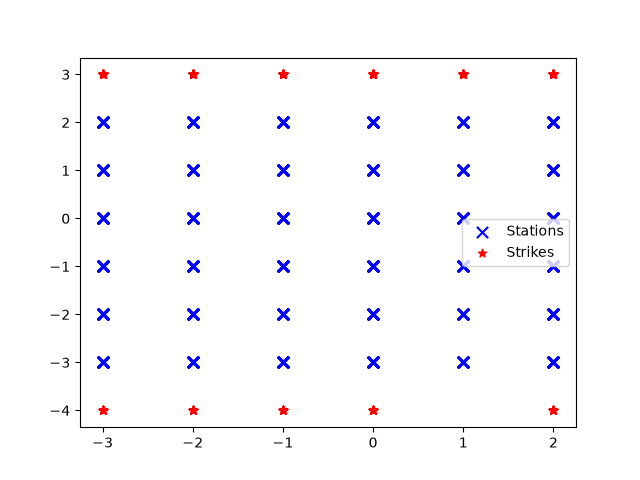

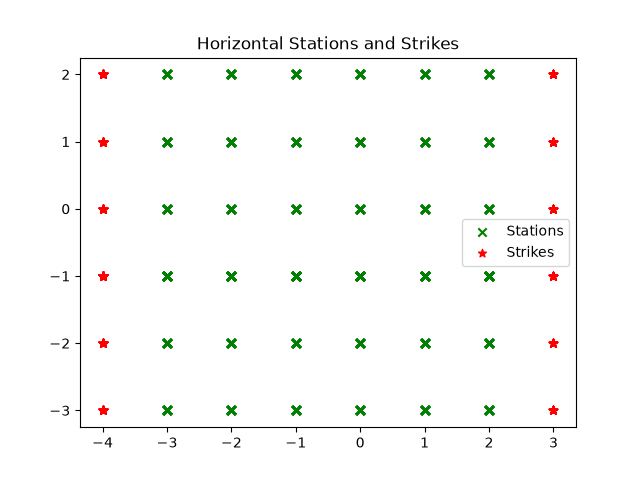

In [5]:
plt.figure()


plt.scatter(df_picks[df_picks['orientation']=='Vertical']['lon'], df_picks[df_picks['orientation']=='Vertical']['lat'], c='b', marker='x', s=65, label='Stations')
# plt.scatter(df_picks[df_picks['orientation'] == 'Horizontal']['lon'], df_picks[df_picks['orientation'] == 'Horizontal']['lat'], c='g', marker='x', label='Stations')
plt.scatter(df_picks[df_picks['orientation']=='Vertical']['ev_lon'], df_picks[df_picks['orientation']=='Vertical']['ev_lat'], c='r', marker='*', label='Strikes')
plt.legend()
plt.show()
plt.title('Vertical Stations and Strikes')
plt.figure()

# plt.scatter(df_picks[df_picks['orientation']=='Vertical']['lon'], df_picks[df_picks['orientation']=='Vertical']['lat'], c='b', marker='x', s=65, label='Stations')
plt.scatter(df_picks[df_picks['orientation'] == 'Horizontal']['lon'], df_picks[df_picks['orientation'] == 'Horizontal']['lat'], c='g', marker='x', label='Stations')
plt.scatter(df_picks[df_picks['orientation'] == 'Horizontal']['ev_lon'], df_picks[df_picks['orientation'] == 'Horizontal']['ev_lat'], c='r', marker='*', label='Strikes')
plt.title('Horizontal Stations and Strikes')
plt.legend()
plt.show()

## Distance vs Time plot with error bars

In [6]:
all_distances = df_picks['distance_to_source'].unique()
all_distances.sort()

df_picks['dt'] = None
df_picks['group'] = None
# Identify the rows where x is 0


for p, phase in enumerate(df_picks['phase'].unique()):
    for k, exp in enumerate(df_picks['experiment'].unique()):
        
        temp = df_picks[(df_picks['experiment']==exp) & (df_picks['phase']==phase)]
        first_station = temp['distance_to_source'].min()

        selected_df_exp = df_picks[(df_picks['distance_to_source'] == first_station) & (df_picks['experiment']==exp) & (df_picks['phase']==phase)]
        
        min_time = selected_df_exp['datetime'].values

        # Subtract these datetime values from the datetime values of rows where x is greater than 0
        count = 0
        for j, times in enumerate(min_time):
            for i, row in df_picks.iterrows():
                if (abs(row['datetime'] - min_time[j]) < 0.1) & (row['experiment'] == exp) & (row['phase']==phase):
                    df_picks.at[i, 'dt'] = row['datetime'] - min_time[j]
                    df_picks.at[i, 'group'] = j
                    # print(j)
                    count += 1
print("Number of all picks collected:", len(df_picks))
print("Number of unique experiments:", len(df_picks['experiment'].unique()))
print("Number of unique stations:", len(df_picks['sta'].unique()))

df_picks.head()

Number of all picks collected: 1493
Number of unique experiments: 23
Number of unique stations: 36


,datetime,session,experiment,net,sta,phase,ev_lat,ev_lon,lat,lon,elev,depth,distance_to_source,orientation,dt,group
0,2024-06-06T17:38:02.234260Z,1,1,SH,39175,P,3.0,-3.0,2.0,-3.0,0,0,1.0,Vertical,0.0,0
1,2024-06-06T17:38:02.240110Z,1,1,SH,33115,P,3.0,-3.0,1.0,-3.0,0,0,2.0,Vertical,0.00585,0
2,2024-06-06T17:38:02.242110Z,1,1,SH,39175,S,3.0,-3.0,2.0,-3.0,0,0,1.0,Vertical,0.0,0
3,2024-06-06T17:38:02.244100Z,1,1,SH,31498,P,3.0,-3.0,0.0,-3.0,0,0,3.0,Vertical,0.00984,0
4,2024-06-06T17:38:02.247960Z,1,1,SH,31640,P,3.0,-3.0,-1.0,-3.0,0,0,4.0,Vertical,0.0137,0


### Plot yor picks

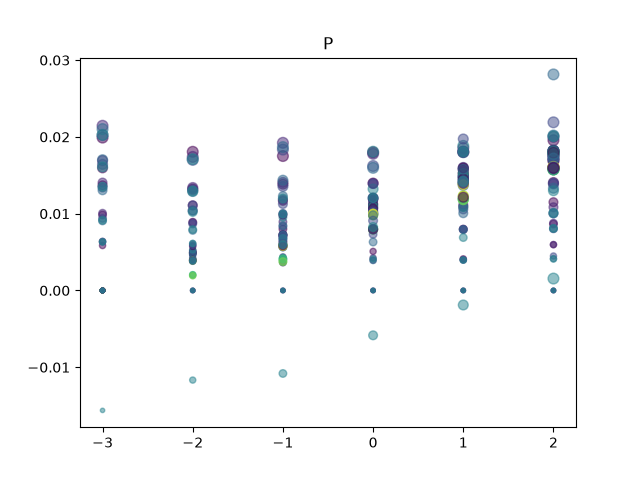

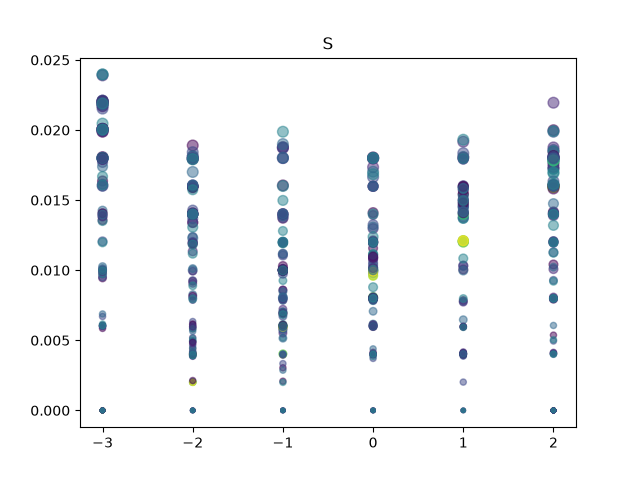

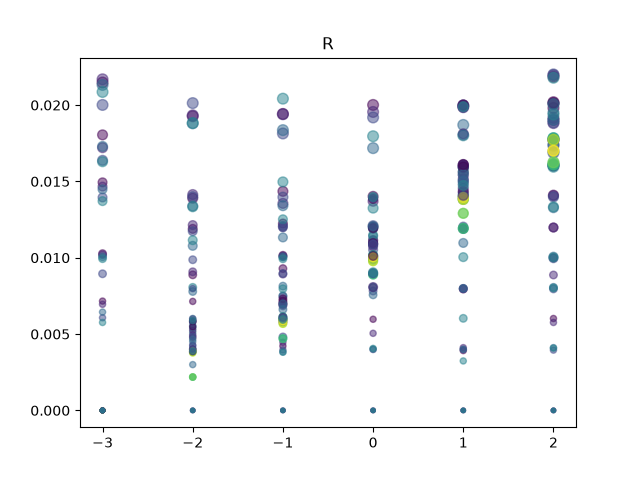

In [7]:
for p, phase in enumerate(df_picks['phase'].unique()):
    plt.figure()
    df_phase = df_picks[df_picks['phase'] == phase]
    # plt.scatter(df_picks['distance_to_source'], df_picks['dt'], s=df_picks['distance_to_source']*10, c=df_picks['group'], cmap='viridis', alpha=0.5)
    plt.scatter(df_phase['lon'], df_phase['dt'], s=df_phase['distance_to_source']*10, c=df_phase['group'], cmap='viridis', alpha=0.5)
    plt.title(f'{phase}')
    plt.show()

### Plot median of picks with error distance vs. dt

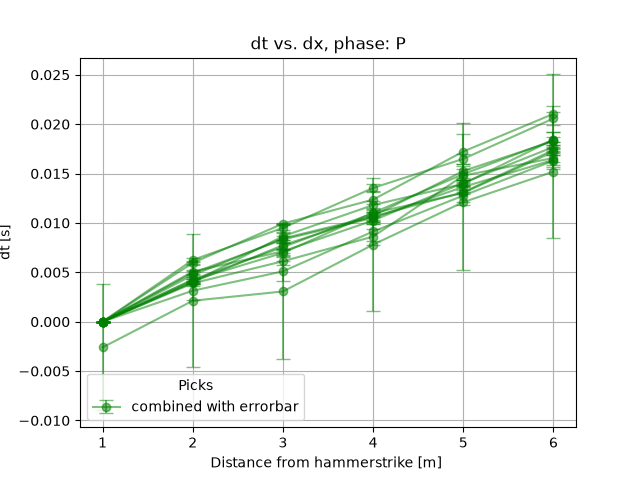

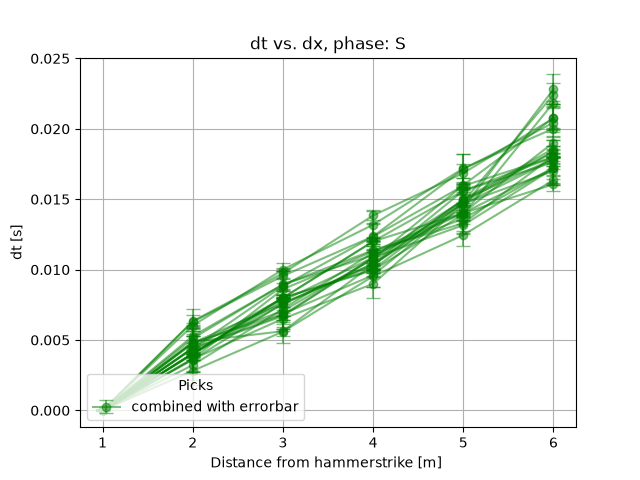

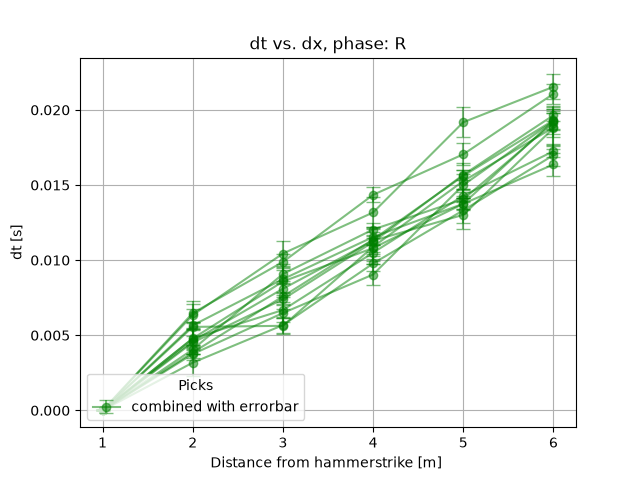

In [8]:
for p, phase in enumerate(df_picks['phase'].unique()):
    plt.figure()
    df_phase = df_picks[df_picks['phase'] == phase]

    for _, exp in enumerate(df_phase['experiment'].unique()):

        df_group = df_phase[df_phase['experiment'] == exp]
        grouped = df_group.groupby('distance_to_source')['dt'].agg(['mean', 'std']).reset_index()

        plt.errorbar(grouped['distance_to_source'], grouped['mean'], yerr=grouped['std'], color='g', fmt='o', linestyle='-', capsize=5, alpha=0.5, label='combined with errorbar')

    # Create a custom legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

    plt.xlabel('Distance from hammerstrike [m] ')
    plt.ylabel('dt [s]')
    plt.title('dt vs. dx, phase: %s' %phase)
    plt.grid(True)
    plt.show()


### Plot median of picks with error x vs. dt
#### and save CSV file with all values

In [ ]:
import matplotlib.colors as mcolors
collect_picks = []

for p, phase in enumerate(df_picks['phase'].unique()):
    df_phase = df_picks[df_picks['phase'] == phase]
    fig, ax = plt.subplots(figsize=(10, 6))

    # cmap = plt.get_cmap('jet_r')  # You can choose other colormaps like 'plasma', 'inferno', etc.
    # # cmap = plt.get_cmap('rainbow')  # You can choose other colormaps like 'plasma', 'inferno', etc.
    # norm = plt.Normalize(df_picks['experiment'].min(), df_picks['experiment'].max())

    # Create a colormap with distinct colors
    cmap = plt.get_cmap('jet_r')  # 'tab10' has 10 distinct colors
    norm = mcolors.Normalize(vmin=0, vmax=len(df_picks['experiment'].unique())-1)
    
    for j, exp in enumerate(df_phase['experiment'].unique()):
        if exp == 49: # leave out experiment 49
            continue
        
        df_group = df_phase[df_phase['experiment'] == exp]
        grouped = df_group.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()
        grouped.rename(columns={'mean': 'mean_dt', 'std': 'std_dt'}, inplace=True)

        df_group = df_group.merge(grouped, on=['lon'], how='left')

        if j % 2 == 0:
            # ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(exp)))
            ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(j)))
        else:
            # ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(exp)))
            ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(j)))
        
        for i, row in df_group.iterrows():
            collect_picks.append([row['datetime'], row['session'],row['experiment'], row['net'], row['sta'], row['phase'], row['ev_lat'], row['ev_lon'], row['lat'], row['lon'], row['elev'], row['depth'], row['distance_to_source'], row['dt'], row['group'], row['mean_dt'], row['std_dt']])
            
            ax.errorbar(row['lon'], row['mean_dt'], yerr=row['std_dt'], fmt='o',  linestyle='-',capsize=5,  color=cmap(norm(j)))

    # print(grouped)

    # Create a custom legend
    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

    ax.set_xlabel('X [m]')
    ax.set_ylabel('dt [s]')
    ax.set_title(f'dt vs. x, phase: {phase}')

    ax.set_ylim(-0.001, 0.04)
    ax.grid(True)
    plt.savefig(os.path.join(save_path, f"dt_vs_x_{phase}.png"))

    plt.show()

df_big = pd.DataFrame(collect_picks, columns = ['datetime', 'session', 'experiment', 'net', 'sta', 'phase', 'ev_lat',
    'ev_lon', 'lat', 'lon', 'elev', 'depth', 'distance_to_source', 'dt',
    'group', 'mean', 'std']) 

df_big.to_csv(os.path.join(save_path, f"combined_strikes_with_mean_std.csv"))


## Picking slopes

In [ ]:
# ## Plotting the data and picking the points for slope calculation
# you have to click on two points to calculate the slope between them - it will be printed below the plot

phase = selectes_phase
df_phase = df_picks[df_picks['phase'] == phase]
fig, ax = plt.subplots(figsize=(10, 6))

cmap = plt.get_cmap('jet_r')  # 'tab10' has 10 distinct colors
norm = mcolors.Normalize(vmin=0, vmax=len(df_picks['experiment'].unique())-1)

for j, exp in enumerate(df_phase['experiment'].unique()):
    
    df_group = df_phase[df_phase['experiment'] == exp]
    grouped = df_group.groupby('lon')['dt'].agg(['mean', 'std']).reset_index()
    grouped.rename(columns={'mean': 'mean_dt', 'std': 'std_dt'}, inplace=True)

    df_group = df_group.merge(grouped, on=['lon'], how='left')

    if j % 2 == 0:
        ax.plot(grouped['lon'], grouped['mean_dt'], 'o-', label=exp,  color=cmap(norm(j)))
    else:
        ax.plot(grouped['lon'], grouped['mean_dt'], 'o--', label=exp,  color=cmap(norm(j)))
    
    for i, row in df_group.iterrows():
        ax.errorbar(row['lon'], row['mean_dt'], yerr=row['std_dt'], fmt='o',  linestyle='-',capsize=5,  color=cmap(norm(j)))

# Create a custom legend
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), title='Picks', loc='lower left')

ax.set_xlabel('X [m]')
ax.set_ylabel('dt [s]')
ax.set_title(f'dt vs. x, phase: {phase}')

ax.set_ylim(-0.001, 0.04)
ax.grid(True)
plt.savefig(os.path.join(save_path, f"dt_vs_x_{phase}.png"))
points = []

cid = fig.canvas.mpl_connect('button_press_event', onclick)
plt.show()

<!-- ## Plot seismograms -->

## Plot seismograms

In [ ]:
# Ensure 'group' column contains only numeric values and handle NaNs
df_big['group'] = pd.to_numeric(df_big['group'], errors='coerce')



if min_exp == max_exp:
    selected_picks = df_big[(df_big['phase'] == phase) & 
                            (df_big['experiment'] == min_exp) & 
                            (df_big['distance_to_source'] <= max_dist_2_source) & 
                            (df_big['distance_to_source'] >= min_dist_2_source)] 
else: 
    selected_picks = df_big[(df_big['phase'] == phase) & 
                            (df_big['experiment'] >= min_exp) & 
                            (df_big['experiment'] <= max_exp) & 
                            (df_big['distance_to_source'] <= max_dist_2_source) & 
                            (df_big['distance_to_source'] >= min_dist_2_source)] 


if min_exp == max_exp:
    # Create a colormap with distinct colors
    cmap = plt.get_cmap('jet')  # 'tab10' has 10 distinct colors
    norm = mcolors.Normalize(vmin=min(selected_picks['experiment'].unique()), vmax=max(selected_picks['experiment'].unique()) + 1)
else: 
        # Create a colormap with distinct colors
    cmap = plt.get_cmap('jet')  # 'tab10' has 10 distinct colors
    norm = mcolors.Normalize(vmin=min(selected_picks['experiment'].unique()), vmax=max(selected_picks['experiment'].unique()) - 1)

# Dictionary to store legend handles
legend_handles = {}

X = None
X_envelope = None
desc_inst = []
desc_dist = []
desc_x = []
desc_y = []
desc_group = []


plt.figure(figsize=(10, 6))

for j, sta_row in selected_picks.iterrows():
    # if sta_row['phase'] != phase:
    #     continue
    # if (sta_row['experiment'] < min_exp):
    #     continue
    # if (sta_row['experiment'] > max_exp):
    #     continue
    number_hammer_strike = sta_row['experiment']
    station = sta_row['sta']
    st = read(glob.glob(os.path.join(path_to_strikewise_folder, f"HS{number_hammer_strike:02d}_*/*{station}*.mseed"))[0])
    if filter[0]:
        st.filter('bandpass', freqmin=filter[1], freqmax=filter[2])

    selected_sta = selected_picks[(selected_picks['sta'] == station) & (selected_picks['phase'] == phase) & (selected_picks['experiment'] == number_hammer_strike)].sort_values('datetime')

    for i, row in selected_sta.iterrows():

        st_sliced = st.copy()

        st_sliced.trim(UTCDateTime(row['datetime'])-row['dt'], UTCDateTime(row['datetime'])+0.1-row['dt'])
        st_sliced[0].taper(0.2, type='cosine')

        data_envelope = obspy.signal.filter.envelope(st_sliced[0].data)

        if X is None:
            X =  st_sliced[0].data
            X_envelope = data_envelope
        else:
            X = np.vstack([X,  st_sliced[0].data])
            X_envelope = np.vstack([X_envelope, data_envelope])
            
        desc_inst.append(row['sta'])
        desc_dist.append(row['distance_to_source'])
        desc_x.append(row['lon'])
        desc_y.append(row['lat'])
        desc_group.append(row['group'])
        
        time_axis = st_sliced[0].times()

        try:
            line, = plt.plot(time_axis, st_sliced[0].data+row['distance_to_source'], color=cmap(norm(row['experiment'])), alpha=0.3)
        except Exception as e:
            print(e)
            continue

        # Add legend handle if not already added
        if row['experiment'] not in legend_handles:
            legend_handles[row['experiment']] = line

plt.xlabel('Time [s]')
plt.ylabel('Distance [m]')
# Create legend
plt.legend(legend_handles.values(), legend_handles.keys(), title='Experiments', loc='upper right')

plt.show()

### Plot Envelope

In [ ]:
plt.figure(figsize=(10, 6))

for i, dist in enumerate(desc_dist):
    line, = plt.plot(time_axis, X_envelope[i]+dist, color='k', alpha=0.1)
plt.show()

### Sanity Check

In [ ]:
plt.figure()
for x in X:
    plt.plot(x, color='k', alpha=0.005)
plt.title('All collected slices from all stations')
plt.show()

In [ ]:
plt.figure()
for x in X_envelope:
    plt.plot(x, color='k', alpha=0.005)
plt.title('All collected slices from all stations')
plt.show()

In [ ]:
if umap_type == 'seismogram':
    X_norm = np.linalg.norm(X, axis=-1)[:, np.newaxis]
else:
    X_norm = np.linalg.norm(X_envelope, axis=-1)[:, np.newaxis]

yy, zz = np.where(X_norm == 0)
for y, z in zip(yy, zz):
    X_norm[y][z] = X_norm[y-1][z]

mapper = umap.UMAP(
n_neighbors=10,  # It determines the number of neighboring points used in local approximations
n_components=10, # This parameter determines the number of dimensions of the space to which the data will be reduced.
metric="cosine",
random_state=1364,
low_memory=False,
min_dist=1.0, # This parameter controls how tightly UMAP packs points together
)

mapper.verbose = True
mapper = mapper.fit(X / X_norm)
dim_red_X = mapper.embedding_

source_train = ColumnDataSource(data=dict(x = dim_red_X[:,0],y = dim_red_X[:,1],
            colors=["#%02x%02x%02x" % (int(r), int(g), int(b)) for r, g, b, _ in 255*mpl.cm.jet(mpl.colors.Normalize()(desc_y))],  
            # desc_soil=desc_soil,
            desc_dist=desc_dist,
            desc_x=desc_x,desc_y=desc_y))

hover_dim = HoverTool( 
                      tooltips=[
                        #   ("Soil", "@desc_soil"), 
                                ("X", "@desc_x"), ("Y", "@desc_y"), ("Distance", "@desc_dist"), ]
                     )


tools_dim = [hover_dim, 'pan', 'wheel_zoom', 'reset', "box_zoom"]
plot_dim = figure(width=800, height=800, tools=tools_dim)

plot_dim.scatter('x', 'y', 
                 size=5, 
                 fill_color='colors', 
                 alpha=0.4, 
                 line_width=0.0, 
                 source=source_train, 
                 name="train")

show(plot_dim)